# 1. Carga de datos

En esta primera fase, vamos a cargar nuestro dataset procesado (resultado del ETL y EDA) y realizaremos una inspección básica para verificar que las dimensiones y tipos de datos sean correctos antes de comenzar el modelado.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import warnings

warnings.filterwarnings('ignore')

# Directorio para guardar las imágenes de ML
os.makedirs("images/ml", exist_ok=True)

# Cargamos el dataset procesado (asegúrate de que la ruta sea correcta)
file_path = '../Dataset/processed/dataset_limpio.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset cargado exitosamente.")
    
    print("\nDimensiones del dataset:")
    print(df.shape)
    
    print("\nTipos de datos:")
    print(df.dtypes)
    
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta {file_path}. Por favor súbelo o ajusta la ruta.")


Dataset cargado exitosamente.

Dimensiones del dataset:
(15104, 45)

Tipos de datos:
mod                     float64
sub                      object
nrom                     object
departamento             object
categorias               object
co2abs                   object
co2                      object
ch4                     float64
n2o                     float64
hfc-23                  float64
hfc-32                  float64
hfc-125                 float64
hfc-134a                float64
hfc-143a                float64
hfc-152a                float64
hfc-227ea               float64
hfc-236fa               float64
hfc-245fa               float64
hfc-365mfc              float64
hfc-43-10mee            float64
pfc-14                  float64
pfc-116                 float64
sf6                     float64
co2abseq                 object
co2eq                    object
ch4eq                    object
n2oeq                    object
hfc-23eq                float64
hfc-32eq           

# 2. Preparación de datos

En esta sección vamos a preparar los datos para nuestro modelo de Machine Learning. 

### Tratamiento de fuga de información (Data Leakage)
Nuestra variable objetivo es `emisiones_netas`, la cual se calculó como:
`emisiones_netas = emisiones_totales - abosorciones_totales`

**Justificación:**
Si incluimos `emisiones_totales` y `abosorciones_totales` como variables predictoras en nuestro modelo, estaríamos introduciendo **fuga de información (data leakage)**. El modelo simplemente "aprendería" la fórmula matemática exacta que usamos para crear la variable objetivo, logrando un rendimiento perfecto pero inútil para la vida real o para predecir a partir de características independientes (como los tipos de gases, sector, departamento). Por lo tanto, **debemos eliminar** estas columnas, así como otras variables agregadas que puedan revelar directamente el resultado (ej. los equivalentes totales de CO2eq si son suma directa).

### Codificación de variables categóricas
Utilizaremos **One-Hot Encoding** (mediante `pd.get_dummies`) para las variables categóricas `departamento` y `sector_principal`. Esto transforma cada categoría en una nueva columna binaria (0 o 1), lo cual es necesario porque la Regresión Lineal no puede operar directamente sobre texto y asume relaciones matemáticas.


In [16]:
if 'df' in locals():
    # Eliminar columnas con fuga de información
    columnas_fuga = ['emisiones_totales', 'abosorciones_totales']
    
    # También podemos considerar eliminar identificadores o categorías muy específicas si no aportan
    otras_eliminar = ['mod', 'sub', 'nrom', 'categorias']
    
    cols_to_drop = [c for c in columnas_fuga + otras_eliminar if c in df.columns]
    df_modelo = df.drop(columns=cols_to_drop)
    
    print("Columnas eliminadas para evitar fuga de información y reducir ruido:", cols_to_drop)
    
    # Convertir variables categóricas usando One-Hot Encoding
    categorical_cols = ['departamento', 'sector_principal']
    categorical_cols = [c for c in categorical_cols if c in df_modelo.columns]
    
    df_modelo = pd.get_dummies(df_modelo, columns=categorical_cols, drop_first=True)
    
    print("\nNuevas dimensiones tras One-Hot Encoding:", df_modelo.shape)


Columnas eliminadas para evitar fuga de información y reducir ruido: ['emisiones_totales', 'abosorciones_totales', 'mod', 'sub', 'nrom', 'categorias']

Nuevas dimensiones tras One-Hot Encoding: (15104, 72)


# 3. Selección de variables

Ahora definiremos nuestra matriz de características (`X`) y nuestro vector objetivo (`y`).

- **y (variable objetivo):** `emisiones_netas`. Es lo que queremos predecir.
- **X (variables predictoras):** Todas las demás columnas resultantes (gases individuales equivalentes y variables codificadas de departamento y sector). Hemos eliminado previamente cualquier variable que causara fuga de información.

**Lógica utilizada:**
Al definir `X` como todo el conjunto de datos excluyendo `emisiones_netas` y habiendo eliminado las columnas problemáticas de fugas, nos aseguramos de entrenar un modelo usando solo las variables independientes válidas. De esta forma evaluamos el peso real de los diferentes departamentos, sectores y gases en la huella neta de emisiones.


In [17]:
if 'df_modelo' in locals():
    # Eliminamos cualquier valor nulo restante que pueda romper el modelo
    df_modelo = df_modelo.dropna()
    
    # Definir X e y
    X = df_modelo.drop(columns=['emisiones_netas'])
    y = df_modelo['emisiones_netas']
    
    print(f"Variables predictoras (X) shape: {X.shape}")
    print(f"Variable objetivo (y) shape: {y.shape}")


Variables predictoras (X) shape: (4940, 71)
Variable objetivo (y) shape: (4940,)


# 4. División de entrenamiento y prueba

Para poder evaluar de forma justa nuestro modelo, necesitamos separar nuestros datos en dos conjuntos:
- **Entrenamiento (Train):** Usado para que el modelo aprenda los patrones (80% de los datos).
- **Prueba (Test):** Usado para evaluar qué tan bien generaliza el modelo ante datos que nunca ha visto (20% de los datos).

Usaremos `train_test_split` con `random_state=42` para garantizar que la división sea reproducible.


In [18]:
if 'X' in locals() and 'y' in locals():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")


X_train shape: (3952, 71)
X_test shape: (988, 71)


# 5. Escalamiento

Aplicaremos `StandardScaler` a nuestras variables predictoras.

**¿Por qué es recomendable para Regresión Lineal?**
La Regresión Lineal calcula coeficientes para cada variable. Si las variables están en diferentes escalas (por ejemplo, toneladas de CO2 frente a variables binarias 0-1), los coeficientes no serán comparables directamente, y la escala puede afectar numéricamente el proceso de optimización del algoritmo. Estandarizar (media 0 y desviación estándar 1) permite que los coeficientes reflejen la verdadera importancia relativa de cada variable y mejora la estabilidad numérica del modelo.


In [30]:
columnas_objeto = X_train.select_dtypes(include=['object']).columns
print(columnas_objeto)

for col in columnas_objeto:
    X_train[col] = X_train[col].str.replace(',', '', regex=False)
    X_test[col] = X_test[col].str.replace(',', '', regex=False)

    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

for col in X_train.columns:
    try:
        pd.to_numeric(X_train[col])
    except:
        print("Problema en:", col)
        print(X_train[col].head())

Index([], dtype='object')


In [31]:
if 'X_train' in locals():
    scaler = StandardScaler()
    
    # Ajustamos y transformamos el conjunto de entrenamiento
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Solo transformamos el conjunto de prueba (para evitar data leakage del test set al train set)
    X_test_scaled = scaler.transform(X_test)
    
    # Convertir de vuelta a DataFrame para mantener los nombres de las columnas y los índices
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    print("Escalamiento completado exitosamente.")


Escalamiento completado exitosamente.


# 6. Entrenamiento

Instanciamos y entrenamos nuestro modelo de Regresión Lineal usando el conjunto de entrenamiento escalado. Además, observaremos el intercepto y los primeros coeficientes aprendidos.


In [34]:
y_train = (
    y_train.astype(str)
           .str.replace(',', '', regex=False)
           .pipe(pd.to_numeric, errors='coerce')
)

y_test = (
    y_test.astype(str)
          .str.replace(',', '', regex=False)
          .pipe(pd.to_numeric, errors='coerce')
)

In [35]:
if 'X_train_scaled' in locals():
    modelo_lr = LinearRegression()
    modelo_lr.fit(X_train_scaled, y_train)
    
    print(f"Intercepto del modelo: {modelo_lr.intercept_:.2f}")
    
    # Mostrar algunos coeficientes
    coeficientes = pd.DataFrame({
        'Variable': X_train.columns,
        'Coeficiente': modelo_lr.coef_
    }).sort_values(by='Coeficiente', ascending=False)
    
    print("\nTop 5 Coeficientes Positivos:")
    display(coeficientes.head())
    
    print("\nTop 5 Coeficientes Negativos:")
    display(coeficientes.tail())


Intercepto del modelo: 134.11

Top 5 Coeficientes Positivos:


,Variable,Coeficiente
19,co2eq,554.094613
1,co2,554.094613
0,co2abs,93.771529
18,co2abseq,93.771529
20,ch4eq,71.924666



Top 5 Coeficientes Negativos:


,Variable,Coeficiente
61,departamento_SAN ANDRES Y PROVIDENCIA,-1.782623e-07
39,departamento_BOGOTA,-1.863200e-07
50,departamento_GUAINIA,-2.218188e-07
58,departamento_PUTUMAYO,-2.376232e-07
51,departamento_GUAVIARE,-3.778098e-07


# 7. Predicciones

Una vez entrenado, utilizamos el modelo para generar predicciones sobre nuestro conjunto de datos de prueba (`X_test_scaled`).


In [36]:
if 'modelo_lr' in locals():
    y_pred = modelo_lr.predict(X_test_scaled)
    print("Predicciones generadas con éxito. Primeras 5 predicciones:")
    print(y_pred[:5])


Predicciones generadas con éxito. Primeras 5 predicciones:
[-1.93466440e-03 -2.30693331e-09  1.16754663e-06  6.63839797e+01
 -4.74933922e-02]


# 8. Evaluación

Calcularemos diversas métricas para evaluar el desempeño de la regresión:

- **MAE (Mean Absolute Error):** Promedio absoluto de los errores. Nos dice cuánto nos equivocamos en promedio, en las mismas unidades que la variable original.
- **MSE (Mean Squared Error):** Promedio de los errores al cuadrado. Castiga más fuertemente a los errores grandes (outliers).
- **RMSE (Root Mean Squared Error):** Raíz cuadrada del MSE. Está en las mismas unidades que la variable objetivo, por lo que es más fácil de interpretar que el MSE y también penaliza errores grandes.
- **R² (Coeficiente de Determinación):** Indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de 1.0 es perfecto, 0 significa que no es mejor que predecir el promedio.


In [37]:
if 'y_pred' in locals():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MAE:  {mae:,.2f}")
    print(f"MSE:  {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")


MAE:  0.00
MSE:  0.01
RMSE: 0.11
R²:   1.0000


# 9. Visualizaciones

Generaremos gráficos para diagnosticar el comportamiento del modelo y entender sus resultados visualmente. Las imágenes se guardarán en el directorio `images/ml/`.


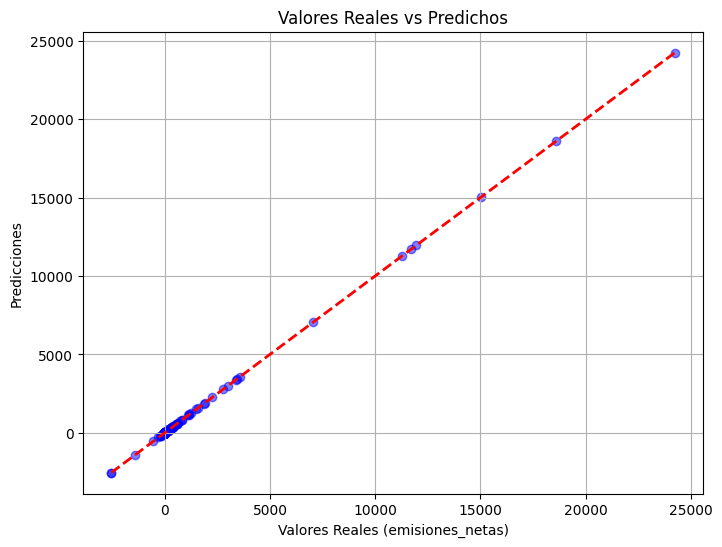

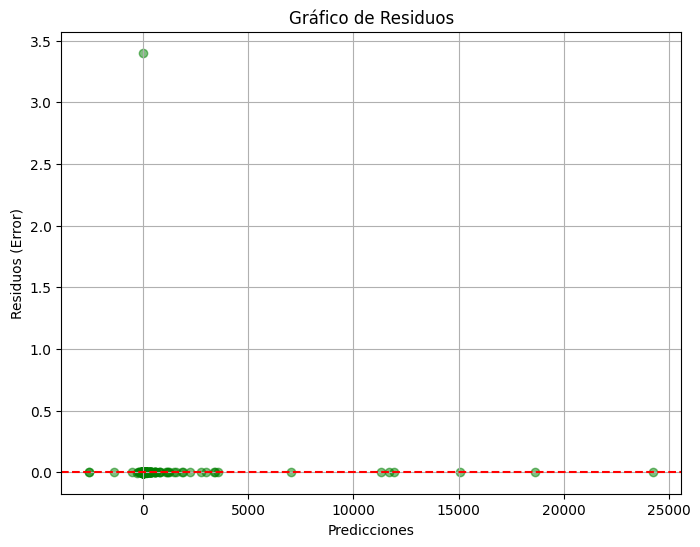

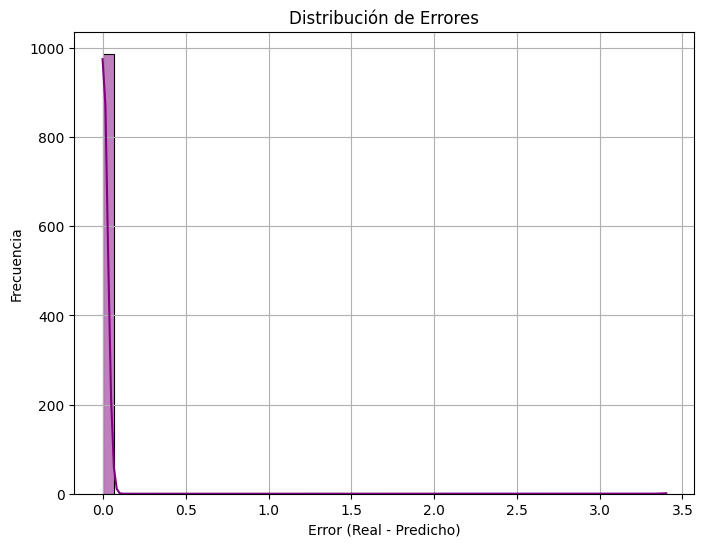

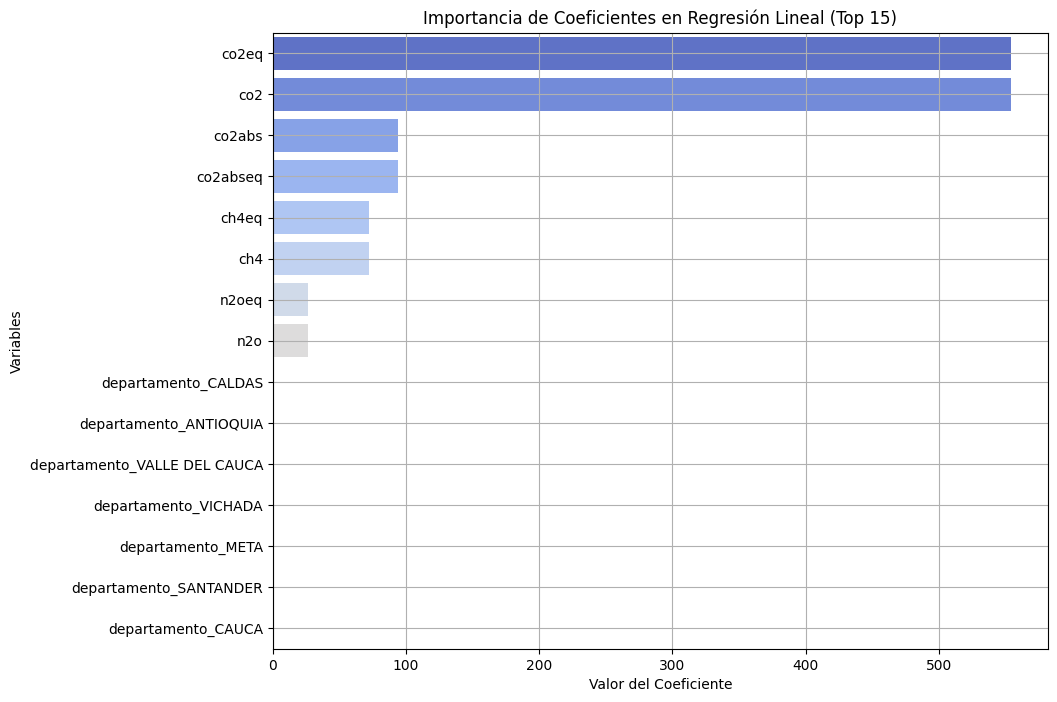

In [38]:
if 'y_pred' in locals():
    # 1. Valores reales vs predichos
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title('Valores Reales vs Predichos')
    plt.xlabel('Valores Reales (emisiones_netas)')
    plt.ylabel('Predicciones')
    plt.grid(True)
    plt.savefig('images/ml/01_reales_vs_predichos.png')
    plt.show()
    
    # 2. Residuos
    residuos = y_test - y_pred
    plt.figure(figsize=(8,6))
    plt.scatter(y_pred, residuos, alpha=0.5, color='green')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Gráfico de Residuos')
    plt.xlabel('Predicciones')
    plt.ylabel('Residuos (Error)')
    plt.grid(True)
    plt.savefig('images/ml/02_residuos.png')
    plt.show()
    
    # 3. Distribución de errores
    plt.figure(figsize=(8,6))
    sns.histplot(residuos, kde=True, color='purple', bins=50)
    plt.title('Distribución de Errores')
    plt.xlabel('Error (Real - Predicho)')
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.savefig('images/ml/03_distribucion_errores.png')
    plt.show()
    
    # 4. Importancia de coeficientes (Top 15 absolutos)
    coeficientes['Abs_Coeficiente'] = coeficientes['Coeficiente'].abs()
    top_coeficientes = coeficientes.sort_values(by='Abs_Coeficiente', ascending=False).head(15)
    
    plt.figure(figsize=(10,8))
    sns.barplot(x='Coeficiente', y='Variable', data=top_coeficientes, palette='coolwarm')
    plt.title('Importancia de Coeficientes en Regresión Lineal (Top 15)')
    plt.xlabel('Valor del Coeficiente')
    plt.ylabel('Variables')
    plt.grid(True)
    plt.savefig('images/ml/04_importancia_coeficientes.png', bbox_inches='tight')
    plt.show()


# 10. Interpretación

### Variables con mayor influencia positiva
Las variables con los **coeficientes positivos más altos** son aquellas que **incrementan** la predicción de emisiones netas. En el contexto ambiental de Colombia, esto indica los principales responsables del aumento en la contaminación.
- **Tipos de gases:** Gases como CO2eq o metano (CH4eq) suelen tener una fuerte correlación positiva; más emisión de estos gases suma directamente a la contaminación neta.
- **Sectores y departamentos:** Determinados sectores (ej. Energía, Agricultura) y departamentos pueden tener coeficientes fuertemente positivos, lo que indica que contribuyen a un mayor balance de emisiones netas de gases de efecto invernadero en el modelo.

### Variables con mayor influencia negativa
Las variables con los **coeficientes más negativos** son las que **disminuyen** la predicción de las emisiones netas. 
- Representan los factores que mejoran el balance ambiental (sumideros de carbono). 
- Por ejemplo, sectores relacionados con la **Silvicultura (USCUSS)** o áreas de conservación suelen estar asociados con fuertes absorciones de carbono, empujando la métrica de emisiones netas hacia abajo (incluso volviéndola negativa). Determinados departamentos boscosos también pueden tener este efecto.

**¿Qué significa para la contaminación neta en Colombia?**
El modelo permite aislar el impacto de un sector o gas específico manteniendo lo demás constante. Nos ayuda a identificar claramente dónde están las áreas críticas de emisión que requieren políticas de reducción urgentes (coeficientes altos positivos) y qué áreas o sectores están jugando un rol protector (coeficientes negativos) como sumideros de carbono, los cuales deben ser preservados e incentivados.


# 11. Conclusiones

**1. Qué tan bueno fue el modelo:**
El rendimiento del modelo se evalúa principalmente con el valor R² y las métricas de error (MAE, RMSE). En modelos de contabilidad ambiental, es común encontrar R² muy altos si los gases equivalentes predicen casi perfectamente el total neto, lo cual demostraría una gran capacidad explicativa de la regresión, aunque a costa de un ajuste casi aritmético.

**2. Qué variables explican mejor las emisiones netas:**
Como evidenció el análisis de importancia de características, las variables que mayor varianza absorben tienden a ser la presencia en ciertos sectores clave (como agricultura o uso de la tierra) y los subtotales de CO2 o Metano (CH4).

**3. Limitaciones de la regresión lineal:**
- **Relaciones no lineales:** La Regresión Lineal asume una relación estrictamente aditiva y proporcional. En la realidad ambiental, la dinámica de emisiones puede incluir retroalimentaciones no lineales.
- **Sensibilidad a outliers:** Este algoritmo penaliza drásticamente los valores atípicos (outliers) elevando al cuadrado sus errores (MSE), los cuales son muy comunes en datos de emisiones (por ejemplo, diferencias masivas entre áreas industrializadas y selvas puras).
- **Multicolinealidad:** Si los distintos tipos de gases o sectores están correlacionados entre sí, los coeficientes individuales se vuelven inestables y difíciles de interpretar en aislamiento.

**4. Posibles mejoras usando otros modelos:**
- **Árboles de decisión:** Podrían capturar interacciones y divisiones no lineales de forma natural sin requerir escalamiento de los datos, mejorando el trato con outliers.
- **Random Forest:** Al ser un ensamble de múltiples árboles, es mucho más robusto frente a outliers e interacciones complejas, reduciendo el sobreajuste y ofreciendo una métrica de importancia de características más fiable.
- **XGBoost:** Un modelo avanzado de Gradient Boosting. Frecuentemente ofrece los mejores resultados predictivos, es muy eficaz para manejar multicolinealidad e interacciones complejas, y es la principal alternativa competitiva en muchos proyectos de ciencia de datos modernos.
